In [2]:
%pip install pymupdf


   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
    --------------------------------------- 0.3/19.2 MB ? eta -:--:--
   -- ------------------------------------- 1.3/19.2 MB 3.1 MB/s eta 0:00:06
   ---- ----------------------------------- 2.4/19.2 MB 3.7 MB/s eta 0:00:05
   --------- ------------------------------ 4.5/19.2 MB 5.1 MB/s eta 0:00:03
   --------------- ------------------------ 7.3/19.2 MB 6.8 MB/s eta 0:00:02
   ----------------------- ---------------- 11.3/19.2 MB 8.8 MB/s eta 0:00:01
   ------------------------- -------------- 12.3/19.2 MB 9.2 MB/s eta 0:00:01
   ----------------------------- ---------- 14.4/19.2 MB 8.5 MB/s eta 0:00:01
   ------------------------------ --------- 14.7/19.2 MB 8.0 MB/s eta 0:00:01
   ------------------------------ --------- 14.7/19.2 MB 8.0 MB/s eta 0:00:01
   ------------------------------- -------- 14.9/19.2 MB 6.5 MB/s eta 0:00:01
   --------------------------------- ------ 16.0/19.2 MB 6.2 MB/s eta 0:00:01
   ---

In [1]:
import fitz  # PyMuPDF
from PIL import Image
import io

pdf_path = r"C:\Users\nupur.sarkar\Documents\Dental_Xray_model\Abigail Joshua_2026-02-07120347.pdf"

doc = fitz.open(pdf_path)
page = doc[0]  # first (and only) page

# Render page to image (high quality)
pix = page.get_pixmap(dpi=300)

img_bytes = pix.tobytes("png")
img = Image.open(io.BytesIO(img_bytes))

img.save("test_opg.png")


(np.float64(-0.5), np.float64(5104.5), np.float64(4204.5), np.float64(-0.5))

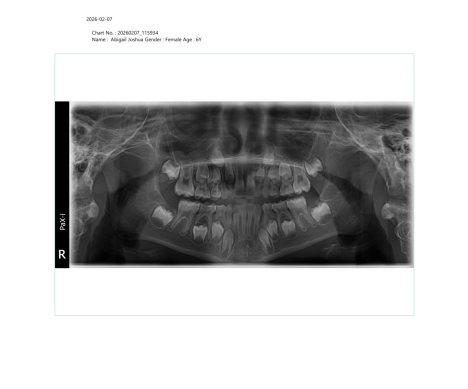

In [2]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis("off")


In [3]:
from torchvision import transforms
import torch
import torchvision.models as models
import torch.nn as nn

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = transform(img).unsqueeze(0)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)
model.load_state_dict(torch.load("best_resnet_finetuned.pt", map_location="cpu"))
model.eval()

with torch.no_grad():
    prob = torch.sigmoid(model(img_tensor)).item()

print(f"Caries probability: {prob:.3f}")


Caries probability: 0.855


In [4]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
from matplotlib import pyplot as plt


In [5]:
features = []
gradients = []

def forward_hook(module, input, output):
    features.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])


In [6]:
target_layer = model.layer4[-1].conv2

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)


In [7]:
model.zero_grad()

output = model(img_tensor)
score = output[0, 0]  # caries score
score.backward()


c:\Users\nupur.sarkar\AppData\Local\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [8]:
grads = gradients[0]          # [1, C, H, W]
fmap = features[0]            # [1, C, H, W]

weights = grads.mean(dim=(2, 3), keepdim=True)
cam = (weights * fmap).sum(dim=1)

cam = F.relu(cam)
cam = cam.squeeze().detach().cpu().numpy()

cam = cv2.resize(cam, (224, 224))
cam = cam / cam.max()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.017274370416998863..1.4].


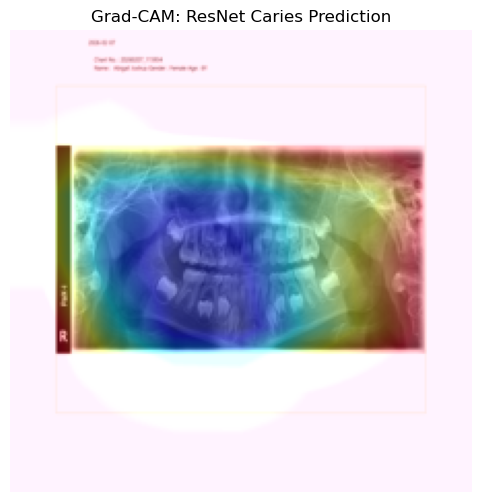

In [9]:
img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = 0.4 * heatmap / 255 + img_np

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM: ResNet Caries Prediction")
plt.show()


In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

# ------------------
# Device
# ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------
# Load image
# ------------------
img = Image.open("test_opg.png").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = transform(img).unsqueeze(0).to(device)

# ------------------
# Load model
# ------------------
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 1)

state_dict = torch.load(
    "best_resnet_finetuned.pt",
    map_location=device
)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

# ------------------
# Inference
# ------------------
with torch.no_grad():
    logits = model(img_tensor)
    prob = torch.sigmoid(logits).item()

print(f"Caries probability: {prob:.3f}")


Caries probability: 0.805
